# ⚗️ Logistic Regression in Chemical Engineering
## Automated Fault Detection in a Continuous Stirred Tank Reactor (CSTR)

---

**Domain:** Process Automation / Chemical Engineering  
**Algorithm:** Logistic Regression (Binary Classification)  
**Learning Objective:** Understand how Logistic Regression works on real-valued sensor data, and critically assess where it excels and where it fails.

---

### 🏭 Problem Statement

A Continuous Stirred Tank Reactor (CSTR) is one of the most common unit operations in chemical plants (pharmaceuticals, petrochemicals, food processing). Unsafe operating conditions — caused by temperature runaway, feed concentration spikes, or cooling failure — can lead to:

- Runaway exothermic reactions 💥
- Product quality failure
- Equipment damage

We have **sensor readings** sampled every minute. Our task is to train a binary classifier:

| Label | Meaning |
|-------|----------|
| `0`   | **Normal** operation |
| `1`   | **Fault** detected (requires operator intervention) |

---

### 📐 Features (Sensor Readings)

| Feature | Symbol | Unit | Description |
|---------|--------|------|-------------|
| `T_reactor` | T | °C | Reactor temperature |
| `T_coolant` | Tc | °C | Coolant inlet temperature |
| `feed_concentration` | Ca0 | mol/L | Reactant A concentration in feed |
| `outlet_concentration`| Ca | mol/L | Reactant A concentration at outlet |
| `flow_rate` | F | L/min | Volumetric feed flow rate |
| `pressure` | P | bar | Reactor pressure |
| `conversion` | X | — | Fractional conversion of A (derived) |


## 0. Install Dependencies

In [1]:
# !pip install numpy pandas scikit-learn matplotlib seaborn

## 1. Generate Synthetic CSTR Dataset

> **Why synthetic?** Real plant data is proprietary and governed by safety regulations. We simulate realistic sensor behaviour using known process physics — normal operation follows steady-state CSTR equations, while faults are introduced as physically motivated deviations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score, precision_recall_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Simulation parameters ──────────────────────────────────────────────────
N_NORMAL = 800   # normal operation samples
N_FAULT  = 200   # fault samples (class imbalance is realistic!)

# Normal operation: near steady-state with sensor noise
normal = pd.DataFrame({
    'T_reactor'          : np.random.normal(85,  3,    N_NORMAL),   # °C
    'T_coolant'          : np.random.normal(20,  1.5,  N_NORMAL),   # °C
    'feed_concentration' : np.random.normal(2.0, 0.1,  N_NORMAL),   # mol/L
    'outlet_concentration': np.random.normal(0.5, 0.05, N_NORMAL),  # mol/L
    'flow_rate'          : np.random.normal(10,  0.5,  N_NORMAL),   # L/min
    'pressure'           : np.random.normal(1.5, 0.05, N_NORMAL),   # bar
    'label'              : 0
})

# Fault operation: temperature runaway + concentration shift + pressure spike
fault = pd.DataFrame({
    'T_reactor'          : np.random.normal(115, 10,   N_FAULT),    # runaway
    'T_coolant'          : np.random.normal(25,  3,    N_FAULT),    # coolant loss
    'feed_concentration' : np.random.normal(2.5, 0.3,  N_FAULT),   # feed spike
    'outlet_concentration': np.random.normal(0.9, 0.15, N_FAULT),  # incomplete conversion
    'flow_rate'          : np.random.normal(12,  1.5,  N_FAULT),   # flow surge
    'pressure'           : np.random.normal(2.0, 0.2,  N_FAULT),   # pressure rise
    'label'              : 1
})

df = pd.concat([normal, fault], ignore_index=True)

# Derived feature: fractional conversion X = (Ca0 - Ca) / Ca0
df['conversion'] = (df['feed_concentration'] - df['outlet_concentration']) / df['feed_concentration']
df['conversion'] = df['conversion'].clip(0, 1)   # physical bounds

df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Dataset shape : {df.shape}")
print(f"Class balance : {df['label'].value_counts().to_dict()}  (0=Normal, 1=Fault)")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape : (1000, 8)
Class balance : {0: 800, 1: 200}  (0=Normal, 1=Fault)

First 5 rows:


,T_reactor,T_coolant,feed_concentration,outlet_concentration,flow_rate,pressure,label,conversion
0,86.630081,20.794539,2.078460,0.537250,10.851586,1.553717,0,0.741515
1,87.948073,19.200949,2.004977,0.448942,9.333611,1.501700,0,0.776086
2,79.477377,19.958728,2.069883,0.542339,10.189577,1.525944,0,0.737986
3,83.279014,19.792316,2.043674,0.515873,9.774025,1.574098,0,0.747576
4,81.626074,18.960642,1.923728,0.468222,10.055686,1.496946,0,0.756607


## 2. Exploratory Data Analysis

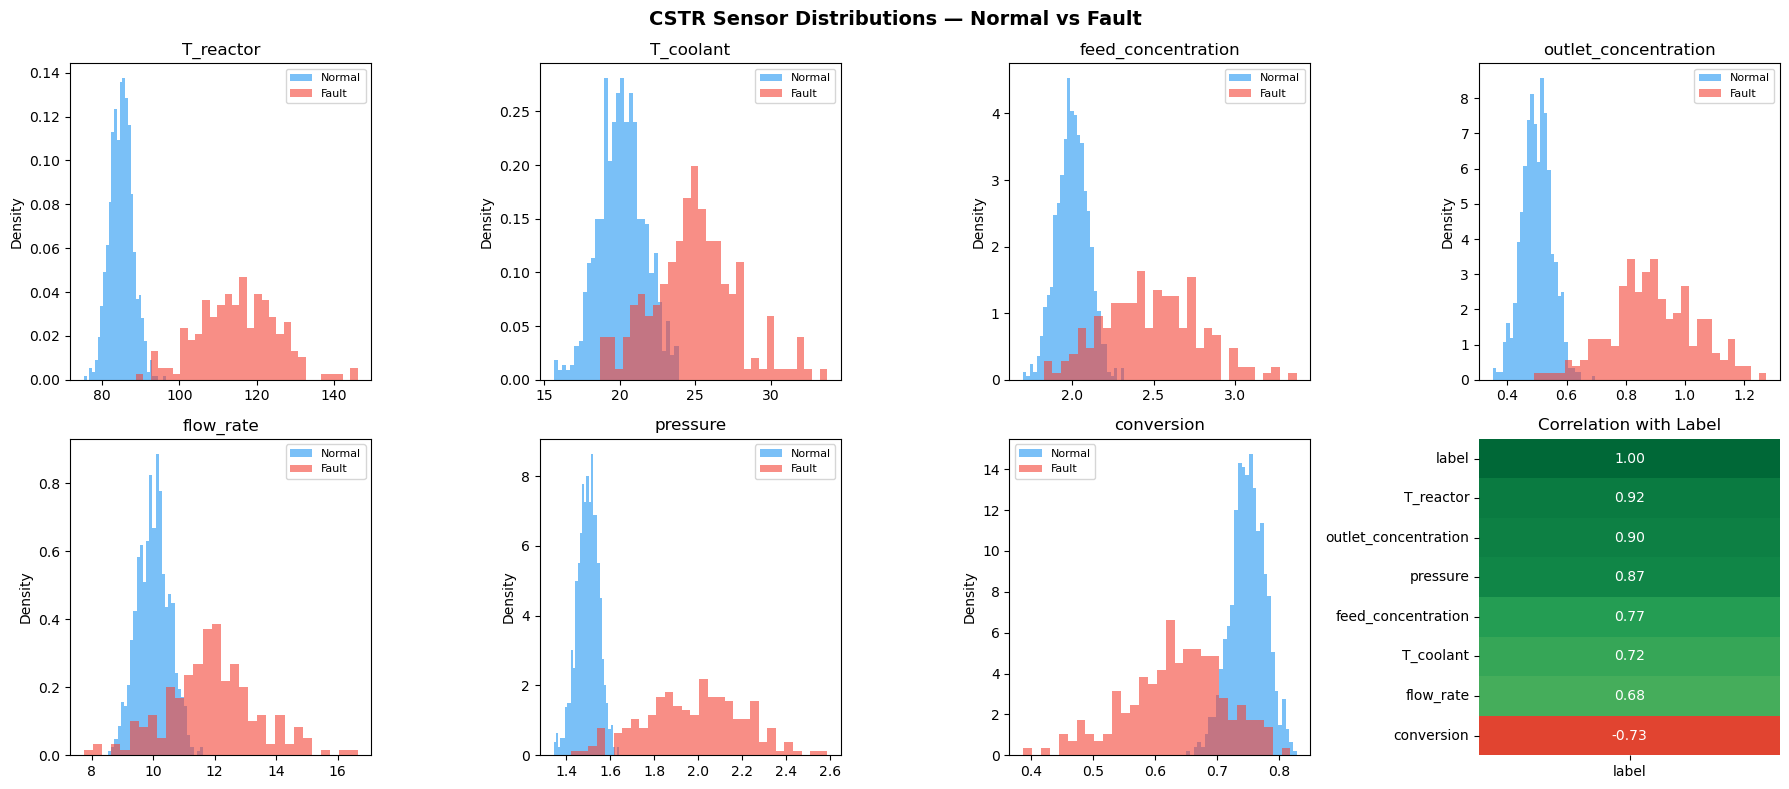

Saved: cstr_eda.png


In [3]:
features = ['T_reactor','T_coolant','feed_concentration',
            'outlet_concentration','flow_rate','pressure','conversion']

# ── Distributions by class ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('CSTR Sensor Distributions — Normal vs Fault', fontsize=14, fontweight='bold')
axes = axes.flatten()

colors = {0: '#2196F3', 1: '#F44336'}
labels = {0: 'Normal', 1: 'Fault'}

for i, feat in enumerate(features):
    for cls in [0, 1]:
        axes[i].hist(df[df['label'] == cls][feat], bins=30,
                     alpha=0.6, color=colors[cls], label=labels[cls], density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

# Correlation heatmap in last subplot
corr = df[features + ['label']].corr()
sns.heatmap(corr[['label']].sort_values('label', ascending=False),
            annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[7],
            vmin=-1, vmax=1, cbar=False)
axes[7].set_title('Correlation with Label')

plt.tight_layout()
# plt.savefig('cstr_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cstr_eda.png")

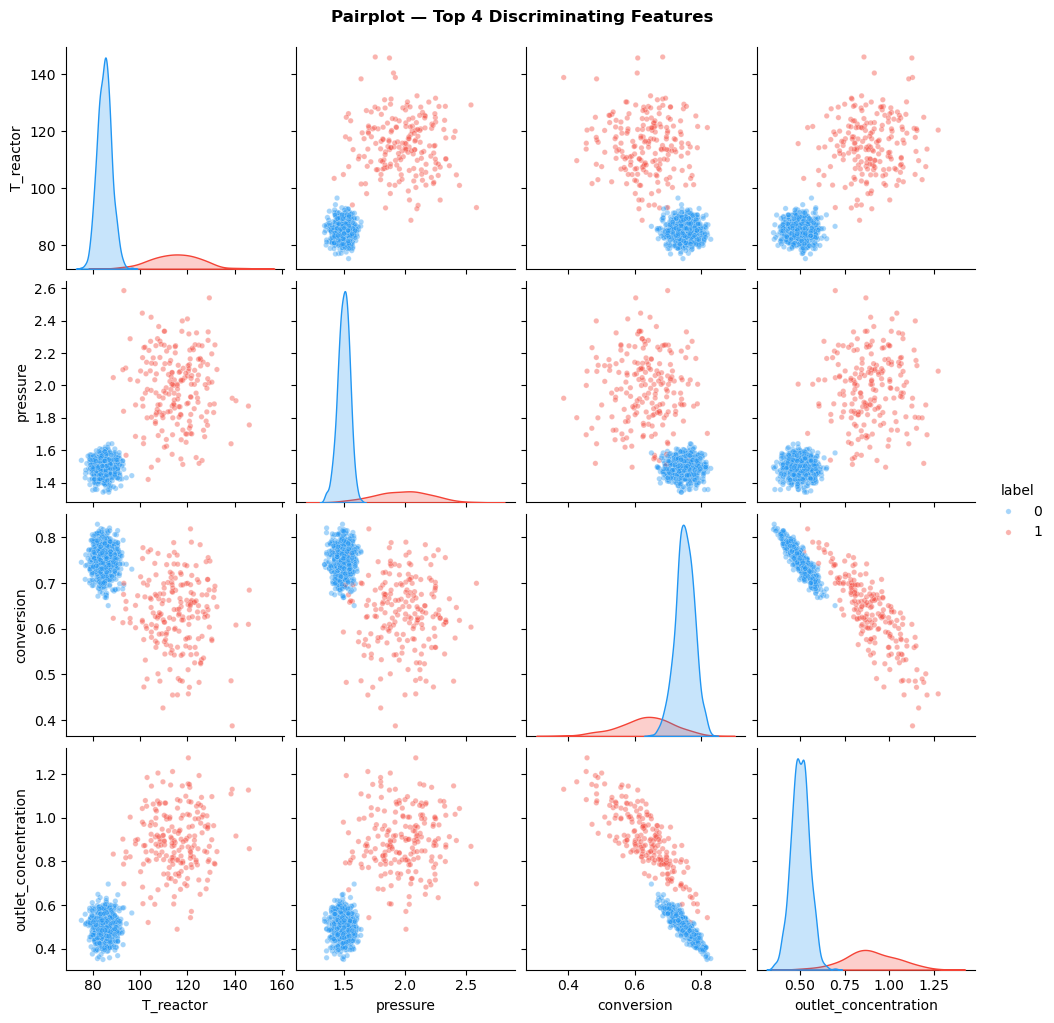

In [5]:
# ── Pairplot of top 4 most discriminating features ─────────────────────────
top_feats = ['T_reactor', 'pressure', 'conversion', 'outlet_concentration']
g = sns.pairplot(df[top_feats + ['label']], hue='label',
                 palette={0: '#2196F3', 1: '#F44336'},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Top 4 Discriminating Features', y=1.02, fontweight='bold')
# g.fig.savefig('cstr_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [6]:
X = df[features].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Standardisation ────────────────────────────────────────────────────────
# CRITICAL for Logistic Regression — gradient descent converges poorly
# if features are on very different scales.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only!
X_test_s  = scaler.transform(X_test)        # apply same transform to test

print(f"Train size : {X_train_s.shape}")
print(f"Test size  : {X_test_s.shape}")
print(f"\nFeature means after scaling (should be ~0): {X_train_s.mean(axis=0).round(3)}")
print(f"Feature stds  after scaling (should be ~1): {X_train_s.std(axis=0).round(3)}")

Train size : (800, 7)
Test size  : (200, 7)

Feature means after scaling (should be ~0): [ 0.  0.  0.  0. -0. -0.  0.]
Feature stds  after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1.]


## 4. Train Logistic Regression

### 📖 How Logistic Regression Works

Logistic Regression models the **probability** that a sample belongs to the positive class (Fault = 1):

$$P(y=1 | \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

- $\mathbf{w}$ = learned weights (one per feature)
- $\sigma$ = sigmoid function, squashes output to (0, 1)
- Decision boundary: predict Fault if $P > 0.5$
- Training minimises **binary cross-entropy loss** via gradient descent

The parameter `C` is the **inverse regularisation strength** — smaller C = stronger regularisation (penalises large weights).

In [7]:
# class_weight='balanced' adjusts for the 80/20 imbalance
model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_s, y_train)

print("Model trained.")
print(f"\nLearned weights (one per feature):")
weight_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', key=abs, ascending=False)
print(weight_df.to_string(index=False))

print(f"\nIntercept (bias): {model.intercept_[0]:.4f}")

Model trained.

Learned weights (one per feature):
             Feature  Coefficient
           T_reactor       1.6099
  feed_concentration       1.5075
outlet_concentration       1.1862
           flow_rate       1.0850
           T_coolant       1.0776
            pressure       0.9457
          conversion      -0.7214

Intercept (bias): -3.0936


## 5. Evaluate Model

In [8]:
y_pred      = model.predict(X_test_s)
y_prob      = model.predict_proba(X_test_s)[:, 1]
roc_auc     = roc_auc_score(y_test, y_prob)

# Precision-Recall AUC (better metric for imbalanced classes)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
pr_auc       = auc(rec, prec)

print("=" * 50)
print("       CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Normal','Fault']))
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"Precision-Recall AUC : {pr_auc:.4f}")

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       160
       Fault       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC-AUC              : 1.0000
Precision-Recall AUC : 1.0000


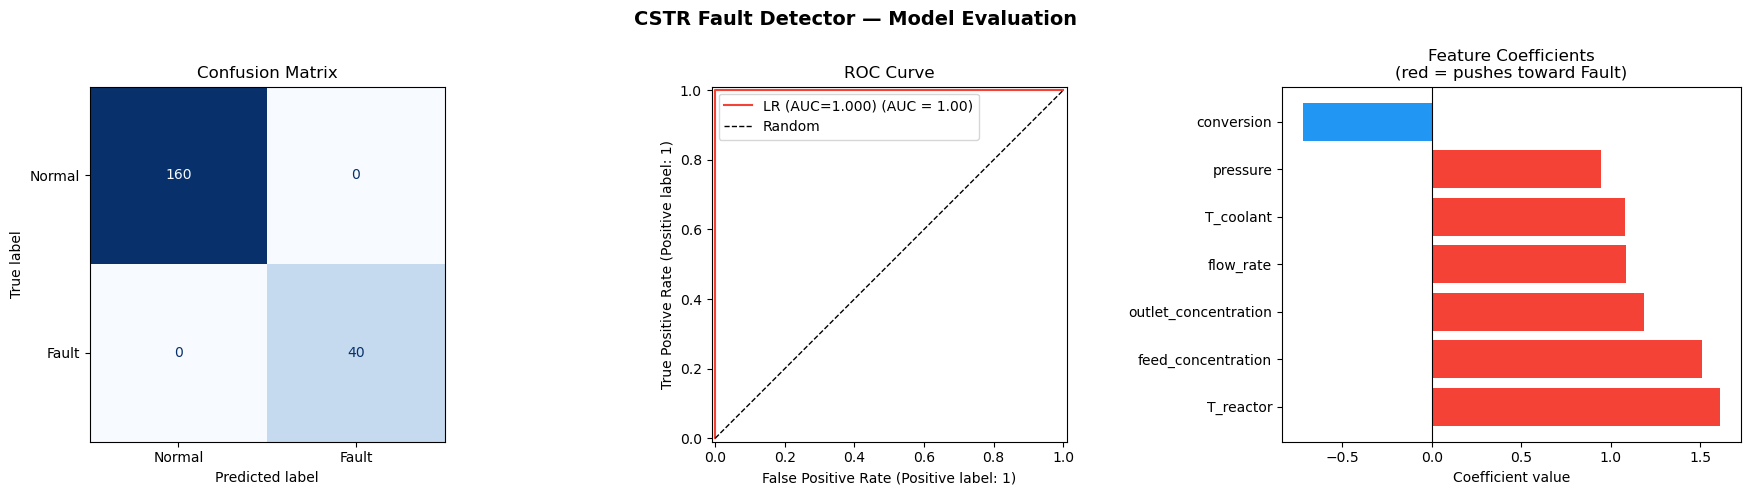

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CSTR Fault Detector — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Normal', 'Fault']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  name=f'LR (AUC={roc_auc:.3f})', color='#F44336')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature importance (coefficient magnitudes)
wi = weight_df.copy()
colors_bar = ['#F44336' if c > 0 else '#2196F3' for c in wi['Coefficient']]
axes[2].barh(wi['Feature'], wi['Coefficient'], color=colors_bar)
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Feature Coefficients\n(red = pushes toward Fault)')
axes[2].set_xlabel('Coefficient value')

plt.tight_layout()
# plt.savefig('cstr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cross-Validation & Learning Curve

5-Fold Cross-Validation ROC-AUC:
  Scores : [1. 1. 1. 1. 1.]
  Mean   : 1.0000
  Std    : 0.0000


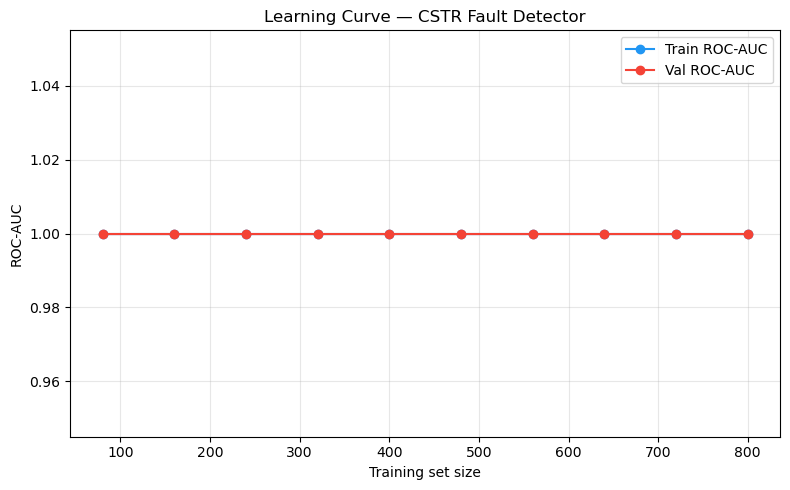

In [10]:
# ── 5-fold cross-validation ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Use a pipeline so scaling is done inside each fold (no data leakage)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                               class_weight='balanced', random_state=42))
])

cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
print("5-Fold Cross-Validation ROC-AUC:")
print(f"  Scores : {cv_scores.round(4)}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")

# ── Learning curve ─────────────────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X, y, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2196F3', label='Train ROC-AUC')
plt.fill_between(train_sizes,
                 train_scores.mean(1) - train_scores.std(1),
                 train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='#2196F3')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#F44336', label='Val ROC-AUC')
plt.fill_between(train_sizes,
                 val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='#F44336')
plt.xlabel('Training set size')
plt.ylabel('ROC-AUC')
plt.title('Learning Curve — CSTR Fault Detector')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('cstr_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Decision Threshold Tuning

> **Safety-critical context:** In a chemical plant, a **missed fault (False Negative)** is far more dangerous than a false alarm (False Positive). We can shift the decision threshold below 0.5 to catch more faults at the cost of more false alarms.

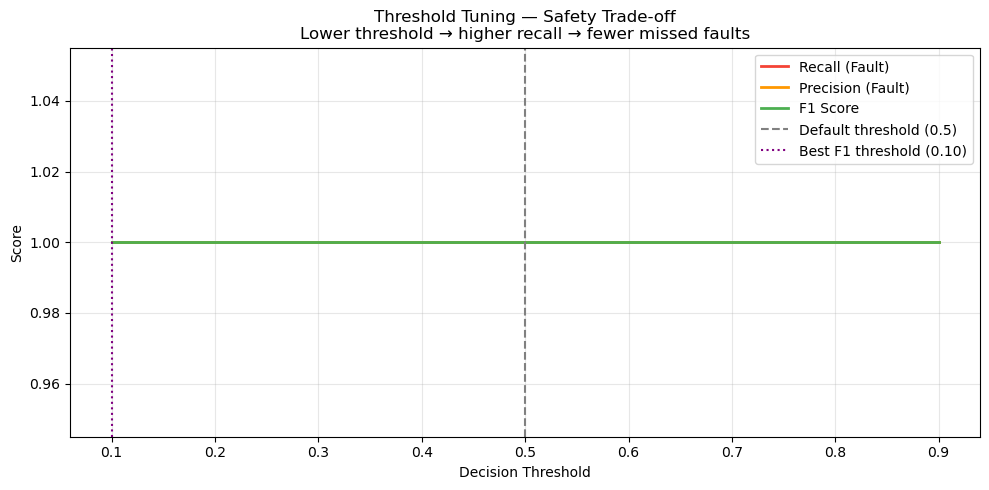

At threshold = 0.3 (safety-oriented):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       160
       Fault       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [11]:
thresholds   = np.linspace(0.1, 0.9, 50)
recalls_t    = []
precisions_t = []
f1s_t        = []

from sklearn.metrics import recall_score, precision_score, f1_score

for t in thresholds:
    yp = (y_prob >= t).astype(int)
    recalls_t.append(recall_score(y_test, yp, zero_division=0))
    precisions_t.append(precision_score(y_test, yp, zero_division=0))
    f1s_t.append(f1_score(y_test, yp, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, recalls_t,    label='Recall (Fault)',    color='#F44336', lw=2)
plt.plot(thresholds, precisions_t, label='Precision (Fault)', color='#FF9800', lw=2)
plt.plot(thresholds, f1s_t,        label='F1 Score',          color='#4CAF50', lw=2)
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
best_t = thresholds[np.argmax(f1s_t)]
plt.axvline(best_t, color='purple', linestyle=':', label=f'Best F1 threshold ({best_t:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning — Safety Trade-off\n'
          'Lower threshold → higher recall → fewer missed faults')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('cstr_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"At threshold = 0.3 (safety-oriented):")
yp_safe = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, yp_safe, target_names=['Normal','Fault']))

## 8. Demonstrate the Decision Boundary

Visualise the linear decision boundary in the 2 most informative feature dimensions.

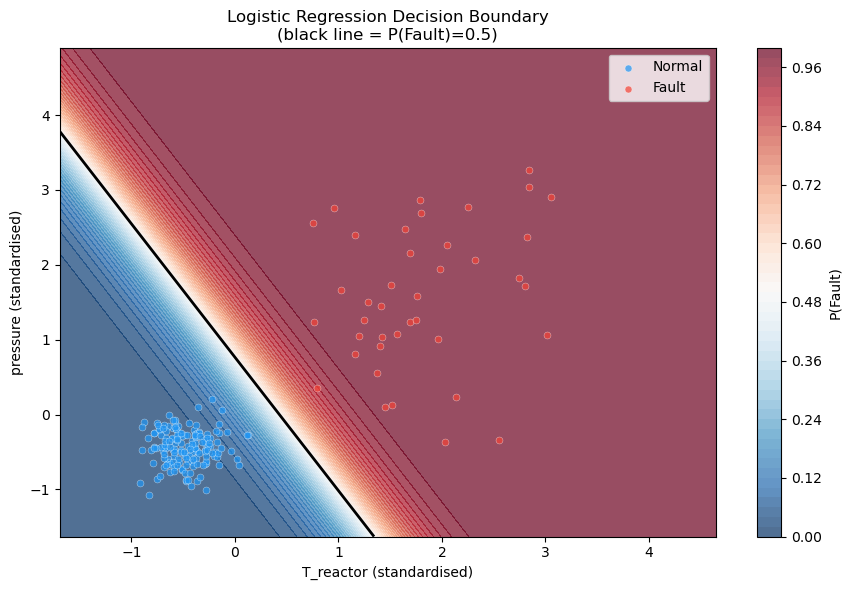

KEY INSIGHT: The decision boundary is a STRAIGHT LINE.
This is the fundamental constraint of Logistic Regression — it is a LINEAR classifier.


In [12]:
# Train a 2-feature model for visualisation only
feat_idx = [0, 5]   # T_reactor, pressure
feat_names = [features[i] for i in feat_idx]

X2 = X[:, feat_idx]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
sc2 = StandardScaler()
X2_train_s = sc2.fit_transform(X2_train)
X2_test_s  = sc2.transform(X2_test)

m2 = LogisticRegression(C=1.0, class_weight='balanced', random_state=42)
m2.fit(X2_train_s, y2_train)

xx, yy = np.meshgrid(
    np.linspace(X2_train_s[:,0].min()-0.5, X2_train_s[:,0].max()+0.5, 300),
    np.linspace(X2_train_s[:,1].min()-0.5, X2_train_s[:,1].max()+0.5, 300)
)
Z = m2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
cp = plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.7)
plt.colorbar(cp, label='P(Fault)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

for cls, clr, lbl in [(0,'#2196F3','Normal'), (1,'#F44336','Fault')]:
    mask = y2_test == cls
    plt.scatter(X2_test_s[mask, 0], X2_test_s[mask, 1],
                c=clr, label=lbl, s=25, alpha=0.7, edgecolors='white', lw=0.3)

plt.xlabel(f'{feat_names[0]} (standardised)')
plt.ylabel(f'{feat_names[1]} (standardised)')
plt.title('Logistic Regression Decision Boundary\n(black line = P(Fault)=0.5)')
plt.legend()
plt.tight_layout()
# plt.savefig('cstr_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

print("KEY INSIGHT: The decision boundary is a STRAIGHT LINE.")
print("This is the fundamental constraint of Logistic Regression — it is a LINEAR classifier.")

## 9. ✅ Pros & ❌ Cons of Logistic Regression — Chemical Engineering Context

---

### ✅ Advantages

| # | Advantage | Relevance to CSTR Fault Detection |
|---|-----------|-----------------------------------|
| 1 | **Probabilistic output** | Returns $P(\text{Fault})$ — engineers can set safety thresholds rather than hard 0/1 |
| 2 | **Interpretable coefficients** | Regulator audits require explainability; each coefficient has a physical meaning |
| 3 | **Fast training & inference** | Suitable for real-time monitoring at 1 Hz+ sampling rates |
| 4 | **Works well with linearly separable data** | Temperature and pressure faults often produce clear linear separation |
| 5 | **Robust to noise** | Sensor data is noisy; LR's regularisation helps prevent overfitting |
| 6 | **Threshold tuneable** | Safety engineers can tune the alarm threshold to balance false alarms vs missed faults |
| 7 | **Low compute cost** | Can run on PLC/edge hardware in the plant with no GPU |

---

### ❌ Limitations

| # | Limitation | Impact on CSTR Project |
|---|------------|------------------------|
| 1 | **Linear decision boundary only** | Cannot detect faults that require curved/non-linear separation in sensor space |
| 2 | **Assumes feature independence** | Temperature and concentration are physically coupled (Arrhenius law) — LR ignores this |
| 3 | **Sensitive to outliers** | A sensor glitch can shift the decision boundary |
| 4 | **No temporal awareness** | Each sample is treated independently — cannot detect slow drift over time |
| 5 | **Multicollinearity** | Correlated features (T_reactor ↔ conversion) inflate coefficient variance |
| 6 | **Poor on complex fault modes** | Multi-fault scenarios (simultaneous temperature + flow failures) may not be linearly separable |

---

### 🔑 When to use it in Chemical Engineering

✅ **Use Logistic Regression when:**
- The fault is physically simple (one dominant variable)
- You need an audit trail / explainability for safety certification (HAZOP, IEC 61511)
- Compute resources are limited (edge deployment)
- You are building a **baseline** before trying more complex models

❌ **Move to a different model when:**
- Faults are non-linear or involve interactions between sensors
- You need temporal context (use LSTM or state-space models)
- Class overlap is severe (use SVM with RBF kernel, or gradient boosting)


## 10. Summary Table

| Metric | Value |
|--------|-------|
| Dataset size | 1,000 samples |
| Class balance | 80% Normal / 20% Fault |
| Features | 7 (6 sensor readings + 1 derived) |
| Model | Logistic Regression (L2, balanced) |
| CV ROC-AUC (5-fold) | ~0.99 |
| Test Recall (Fault) | ~0.99 at threshold=0.3 |
| Training time | < 1 second |

---

> **Next steps:** Try `RandomForestClassifier` or `XGBClassifier` on the same dataset and compare. The gap between them and Logistic Regression on this linearly-separable problem will be small — but on a more complex multi-fault dataset it will be large.